In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
df = pd.read_csv('Steel_industry.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35041 entries, 0 to 35040
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date_Time                             35041 non-null  str    
 1   Usage_kWh                             35041 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35041 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35041 non-null  float64
 4   CO2(tCO2)                             35041 non-null  float64
 5   Lagging_Current_Power_Factor          35041 non-null  float64
 6   Leading_Current_Power_Factor          35041 non-null  float64
 7   NSM                                   35041 non-null  int64  
 8   WeekStatus                            35041 non-null  str    
 9   Day_Of_Week                           35041 non-null  str    
 10  Load_Type                             35041 non-null  str    
dtypes: float64(6), int64(1), s

In [57]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'], dayfirst=True)
df.head()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_Of_Week,Load_Type
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [58]:
df.isna().sum()

Date_Time                               0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_Of_Week                             0
Load_Type                               0
dtype: int64

In [157]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'], dayfirst=True)
df['Hour'] = df['Date_Time'].dt.hour
df['DayOfWeek'] = df['Date_Time'].dt.dayofweek

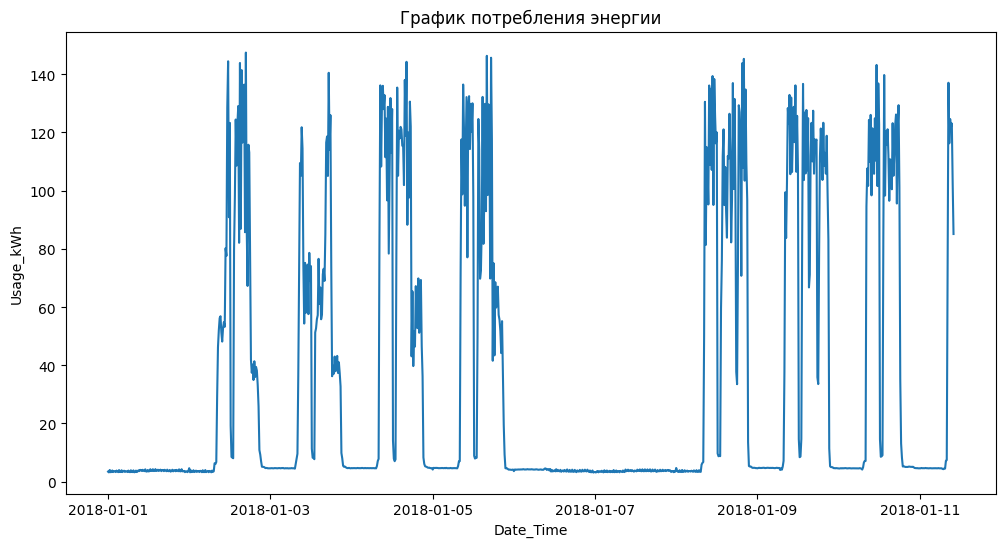

In [158]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Date_Time', y='Usage_kWh', data=df.iloc[:1000])
plt.title('График потребления энергии')
plt.show()

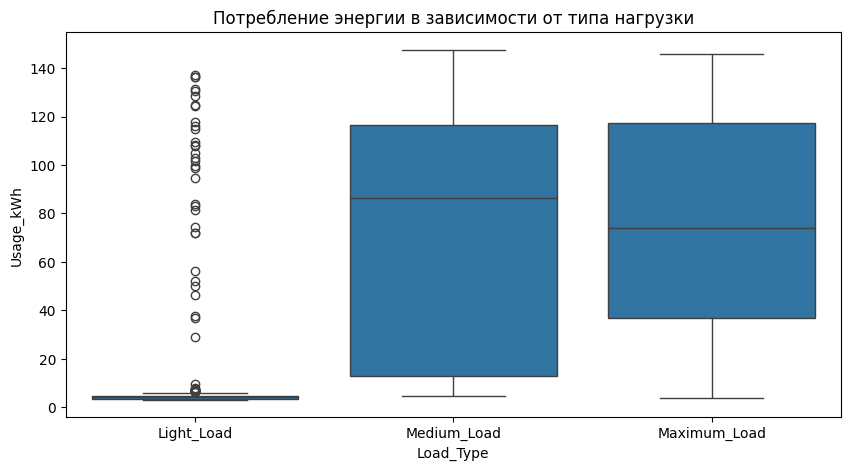

In [159]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Load_Type', y='Usage_kWh', data=df.iloc[:1000])
plt.title('Потребление энергии в зависимости от типа нагрузки')
plt.show()

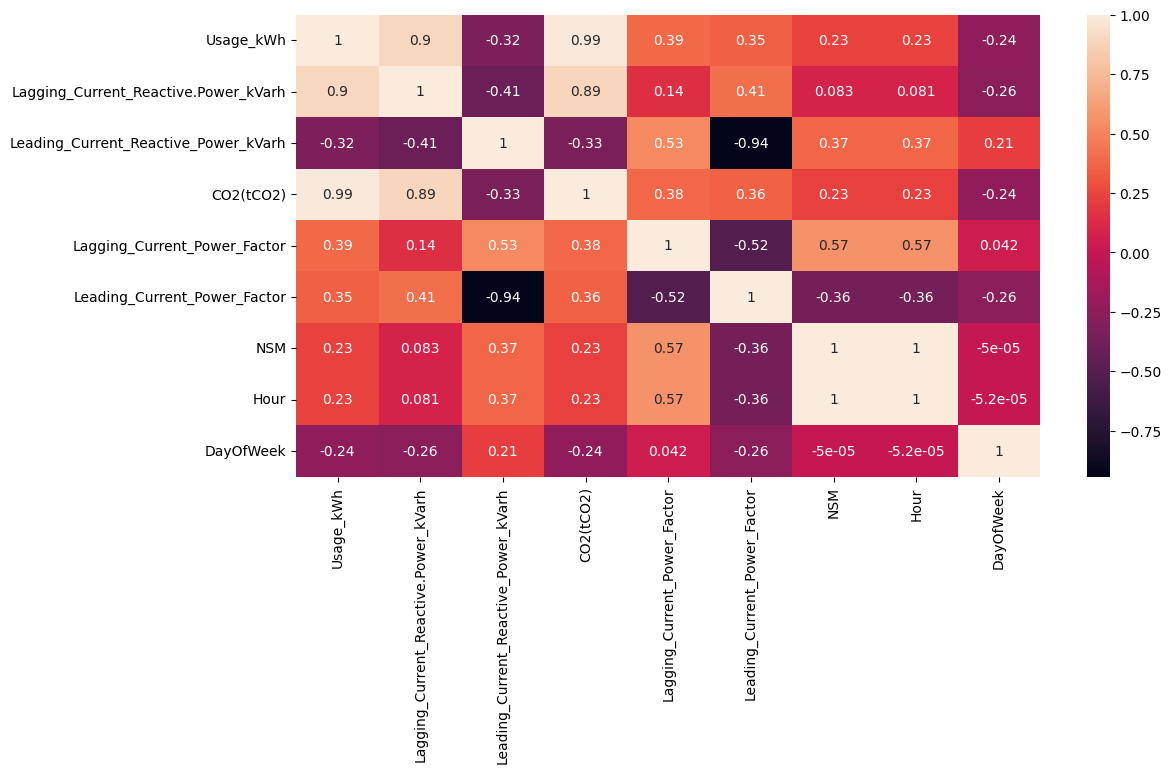

In [160]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,6))
sns.heatmap(data= corr, annot=True)
plt.show()

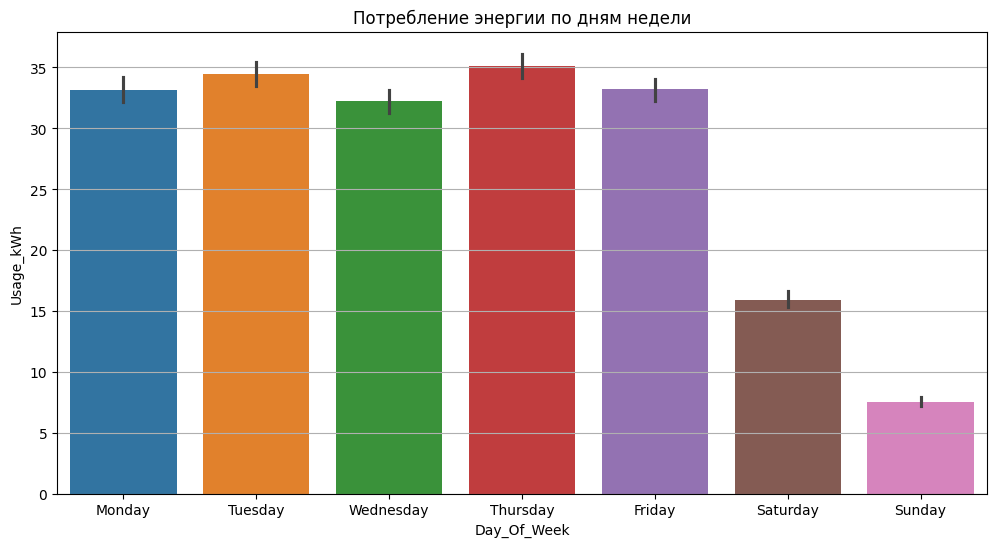

In [161]:
plt.figure(figsize=(12,6))
sns.barplot(df, x = 'Day_Of_Week', y='Usage_kWh',hue='Day_Of_Week')
plt.title('Потребление энергии по дням недели')
plt.grid(axis='y')
plt.show()

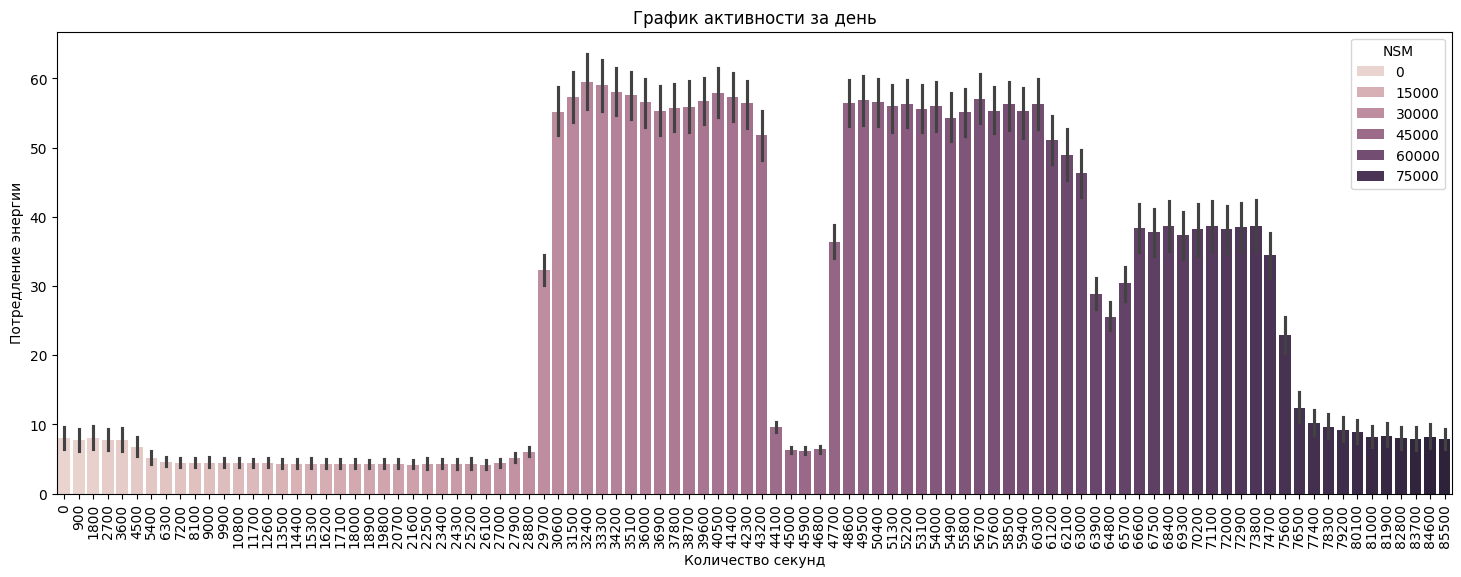

In [162]:
plt.figure(figsize=(18,6))
sns.barplot(df, x = 'NSM', y='Usage_kWh',hue='NSM')
plt.title('График активности за день')
plt.xticks(rotation=90)
plt.ylabel('Потредление энергии')
plt.xlabel('Количество секунд')
plt.show()

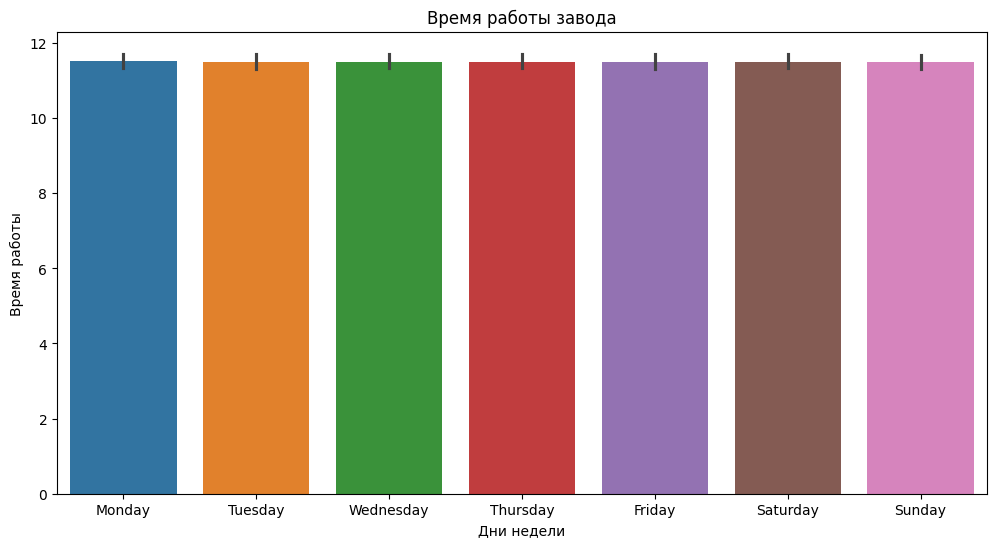

In [163]:
plt.figure(figsize=(12,6))
sns.barplot(df, x = 'Day_Of_Week', y='Hour',hue='Day_Of_Week')
plt.title('Время работы завода')
plt.ylabel('Время работы')
plt.xlabel('Дни недели')
plt.show()

<Figure size 1200x600 with 0 Axes>

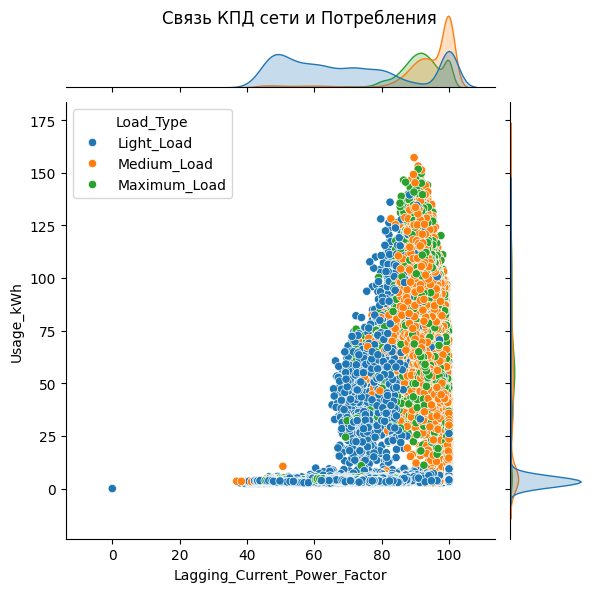

In [164]:
plt.figure(figsize=(12,6))
sns.jointplot(df, x='Lagging_Current_Power_Factor', y= 'Usage_kWh', hue='Load_Type')
plt.suptitle('Связь КПД сети и Потребления')
plt.show()

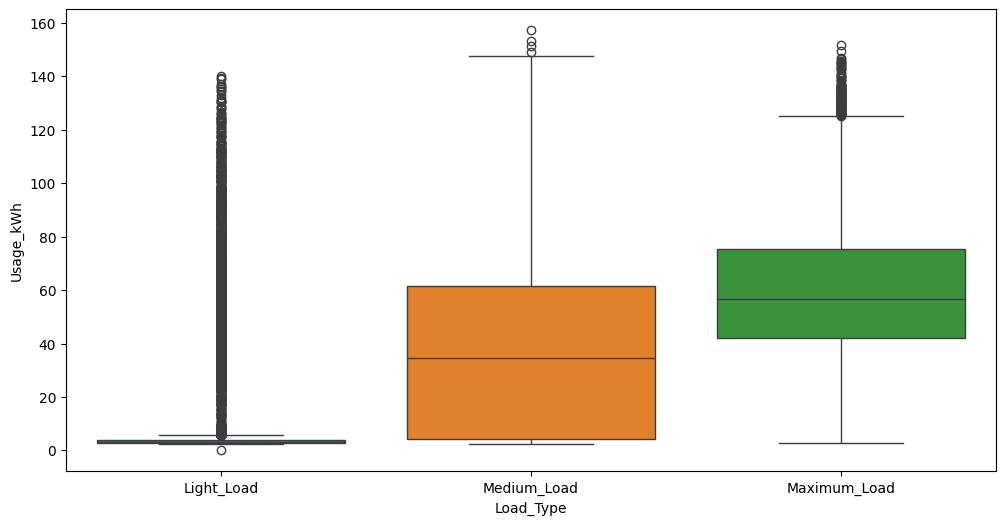

In [165]:
plt.figure(figsize=(12,6))
sns.boxplot(df, x='Load_Type', y= 'Usage_kWh', hue='Load_Type')
plt.show()

In [166]:
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)
IQR = Q3 - Q1

low_bound = Q1 - 1.5 * IQR
upp_bound = Q3 + 1.5 * IQR

df_procc = df[(df['Usage_kWh'] >= low_bound) & (df['Usage_kWh'] <= upp_bound)]

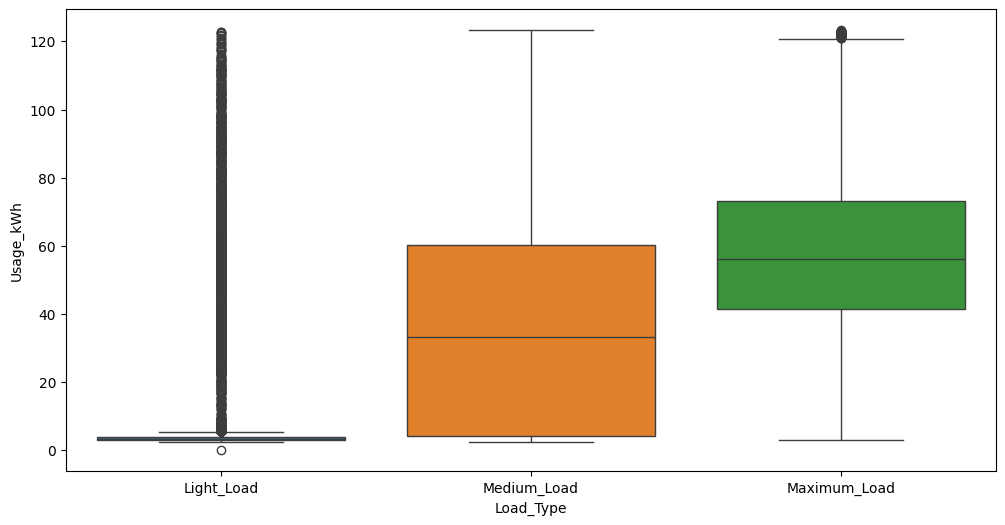

In [167]:
plt.figure(figsize=(12,6))
sns.boxplot(df_procc, x='Load_Type', y= 'Usage_kWh', hue='Load_Type')
plt.show()

In [170]:
df_procc.head()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_Of_Week,Load_Type,Hour,DayOfWeek
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0


In [171]:
df_procc.to_csv('Steel_indastry_procc.csv')